# Evaluate the text recognizers on the held-out test receipts

Compares, on the **test split** (30 receipts never used for training or checkpoint selection):

| Model | Checkpoint |
|---|---|
| First recognizer, ViT → BERT (`training/train_trocr.py`) | `checkpoints/trocr/best` |
| `microsoft/trocr-base-printed`, zero-shot | downloaded from Hugging Face |
| `trocr-base-printed` fine-tuned on our receipts (`notebooks/train_trocr_printed.ipynb`) | `checkpoints/trocr-printed/best` |

Everything goes through `ocr/inference.py`, **the same code the pipeline runs**: same crops, same preprocessing,
same decoding. Sections: 1) scores on ground-truth word boxes, 2) what errors remain, 3) whether confidence flags
them, 4) end to end with the DBNet detector.

**Where to run it.** On Colab (Runtime → GPU) it takes a few minutes; it mounts Drive, clones the repo and reads the
checkpoints from `MyDrive/document-processing/checkpoints/`. Locally it reads `checkpoints/` and takes about an hour on
CPU, mostly beam search. Note that the two `trocr/best` files differ: Drive has the later one (25 Sept 14:40).

For reference, the training run (`train_trocr_printed.ipynb`) scored the fine-tuned model at **CER 0.031, 90% exact
words** on this test split (beam 4).

## Setup

In [1]:
import os, subprocess, sys
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    try:  # for a private repo, add a GITHUB_TOKEN secret in the Colab sidebar (key icon)
        from google.colab import userdata
        token = userdata.get("GITHUB_TOKEN")
    except Exception:
        token = None
    REPO_DIR = "/content/document-processing"
    repo_url = f"https://{token + '@' if token else ''}github.com/alexisvannson/document-processing.git"
    if os.path.isdir(REPO_DIR):
        subprocess.run(["git", "-C", REPO_DIR, "pull", "-q"], check=True)
    else:
        subprocess.run(["git", "clone", "-q", repo_url, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "albumentations>=2.0", "scikit-image",
                    "pyclipper", "shapely"], check=True)
    subprocess.run(["rsync", "-a", "/content/drive/MyDrive/dataset_receipt/", "/content/dataset_receipt/"], check=True)
    DATA_DIR = "/content/dataset_receipt"
    CKPT_DIR = "/content/drive/MyDrive/document-processing/checkpoints"
else:
    if not os.path.isdir("dataset_receipt") and os.path.isdir("../dataset_receipt"):
        os.chdir("..")
    DATA_DIR, CKPT_DIR = "dataset_receipt", "checkpoints"
print("repo:", os.getcwd(), "| data:", DATA_DIR, "| checkpoints:", CKPT_DIR)

Mounted at /content/drive
repo: /content/document-processing | data: /content/dataset_receipt | checkpoints: /content/drive/MyDrive/document-processing/checkpoints


In [2]:
import collections, difflib, re, time, warnings
warnings.filterwarnings("ignore", message="IProgress not found")
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()

from ocr.dataset import split_receipts
from ocr.inference import OCRModel
from training.train_dbnet import polygon_iou
from training.train_trocr import edit_distance

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
MODELS = {
    "first (ViT → BERT)": f"{CKPT_DIR}/trocr/best",
    "TrOCR zero-shot": "microsoft/trocr-base-printed",
    "TrOCR fine-tuned": f"{CKPT_DIR}/trocr-printed/best",
}
DBNET = f"{CKPT_DIR}/dbnet_best.pt"
FINE_TUNED = "TrOCR fine-tuned"
BLIND_WORDS = 100  # words re-read from a white image, to check the model uses the image

_, _, test_df = split_receipts(pd.read_pickle(f"{DATA_DIR}/metadata.pkl"), seed=42)
receipts = []
for row in test_df.itertuples():
    image = cv2.cvtColor(cv2.imread(f"{DATA_DIR}/images/{row.file_name}"), cv2.COLOR_BGR2RGB)
    quads = [[[b[f"x{k}"], b[f"y{k}"]] for k in range(1, 5)] for b in row.bboxes]
    receipts.append((row.file_name, image, quads, list(row.words)))
truths = [w for *_, words in receipts for w in words]
print(f"test split: {len(receipts)} receipts, {len(truths)} words | device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

test split: 30 receipts, 629 words | device: cuda


## 1. Scores on the ground-truth word boxes

In [3]:
AMOUNT = re.compile(r"^[-(]?(rp\.?\s*)?@?\d{1,3}([.,]\d{3})+([.,]\d{2})?\)?$|^\d+$", re.I)
def word_class(w):
    return "number" if AMOUNT.match(w.strip(":")) else "word" if re.fullmatch(r"[A-Za-z]+[.:]?", w) else "other"

def cer(preds, refs):
    return sum(edit_distance(p, t) for p, t in zip(preds, refs)) / max(sum(len(t) for t in refs), 1)

def read_all(model, num_beams=None):
    preds, confs = [], []
    for _, image, quads, _ in receipts:
        texts, conf = model.recognize(image, quads, num_beams=num_beams)
        preds += [t.strip() for t in texts]; confs += conf
    return preds, confs

def blind_read(model):
    """The first BLIND_WORDS boxes, read from a white image instead of the receipt."""
    preds, n = [], 0
    for _, image, quads, _ in receipts:
        take = quads[:BLIND_WORDS - n]
        preds += [t.strip() for t in model.recognize(np.full_like(image, 255), take)[0]]
        n += len(take)
        if n >= BLIND_WORDS:
            break
    return preds

results, outputs = [], {}
for name, path in MODELS.items():
    model = OCRModel(dbnet_path=DBNET, recognizer_path=path)
    for beams in ([None, 4] if name == FINE_TUNED else [None]):
        label = name + (f", beam {beams}" if beams else "")
        start = time.time(); preds, confs = read_all(model, beams); seconds = time.time() - start
        outputs[label] = (preds, confs)
        row = {"model": label, "CER": cer(preds, truths), "exact words": np.mean([p == t for p, t in zip(preds, truths)])}
        for cls in ("number", "word", "other"):
            idx = [i for i, t in enumerate(truths) if word_class(t) == cls]
            row[f"CER {cls}s"] = cer([preds[i] for i in idx], [truths[i] for i in idx])
        if beams is None:
            row["blind CER"] = cer(blind_read(model), truths[:BLIND_WORDS])
        row["s / word"] = seconds / len(truths)
        results.append(row); print(f"{label}: CER {row['CER']:.3f} ({seconds:.0f}s)")
    del model

scores = pd.DataFrame(results).set_index("model")
print()
print(scores.to_string(float_format=lambda v: f"{v:.3f}"))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 180MB/s]


Loading weights:   0%|          | 0/520 [00:00<?, ?it/s]

first (ViT → BERT): CER 0.702 (20s)


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


...

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

/usr/local/lib/python3.13/dist-packages/transformers/generation/utils.py:1676: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


TrOCR zero-shot: CER 0.258 (22s)


Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

TrOCR fine-tuned: CER 0.032 (22s)
TrOCR fine-tuned, beam 4: CER 0.031 (56s)

                           CER  exact words  CER numbers  CER words  CER others  blind CER  s / word
model                                                                                               
first (ViT → BERT)       0.702        0.121        0.481      0.823       0.932      1.027     0.032
TrOCR zero-shot          0.258        0.666        0.017      0.428       0.343      0.948     0.035
TrOCR fine-tuned         0.032        0.903        0.008      0.035       0.107      0.910     0.035
TrOCR fine-tuned, beam 4 0.031        0.905        0.008      0.031       0.107        NaN     0.089


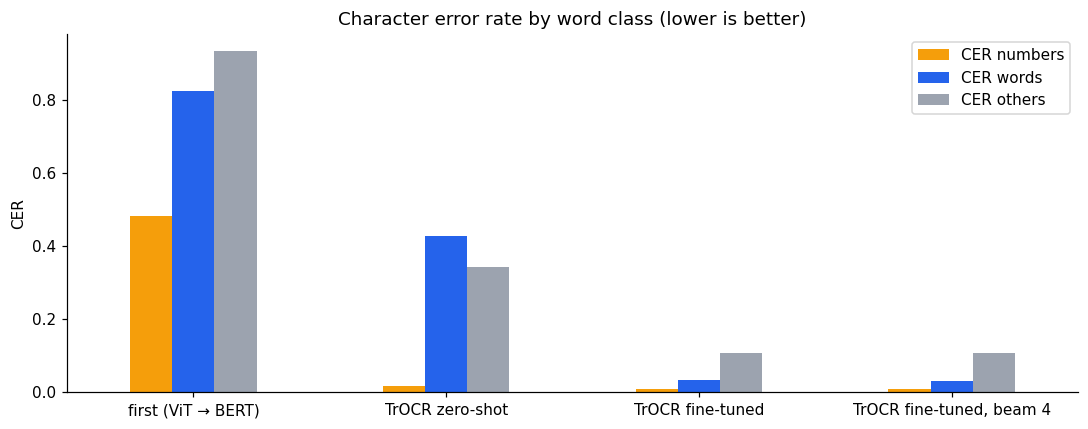

In [4]:
ax = scores[["CER numbers", "CER words", "CER others"]].plot.bar(
    figsize=(10, 4), color=["#F59E0B", "#2563EB", "#9CA3AF"], rot=0,
    title="Character error rate by word class (lower is better)")
ax.set_ylabel("CER"); ax.set_xlabel("")
plt.tight_layout(); plt.show()

## 2. What errors remain

The fine-tuned model's errors, sorted into kinds: only the case differs, only a `,` / `.` separator differs, only
other punctuation or spaces differ, a digit is wrong, or anything else. Then the most frequent character
substitutions.

In [5]:
best = min((label for label in outputs if label.startswith(FINE_TUNED)), key=lambda l: scores.loc[l, "CER"])
preds, confs = outputs[best]
print("analysing:", best)

def error_kind(p, t):
    if p.lower() == t.lower():
        return "case only"
    if re.sub(r"[.,]", "", p) == re.sub(r"[.,]", "", t):
        return "separator , vs . only"
    alnum = lambda s: re.sub(r"[^0-9A-Za-z]", "", s)
    if alnum(p).lower() == alnum(t).lower():
        return "other punctuation / spaces"
    if any(c.isdigit() for c in t):
        return "digit error"
    return "letter error"

errors = [(t, p, c) for t, p, c in zip(truths, preds, confs) if p != t]
kinds = pd.Series([error_kind(p, t) for t, p, _ in errors]).value_counts()
print(f"{len(errors)} of {len(truths)} words wrong ({len(errors) / len(truths):.1%})")
print(pd.DataFrame({"words": kinds, "share of errors": (kinds / len(errors)).map("{:.0%}".format)}).to_string())

subs = collections.Counter()
for t, p, _ in errors:
    for op, i1, i2, j1, j2 in difflib.SequenceMatcher(None, t, p).get_opcodes():
        if op == "replace":
            subs[(t[i1:i2], p[j1:j2])] += 1
        elif op == "delete":
            subs[(t[i1:i2], "∅")] += 1
        elif op == "insert":
            subs[("∅", p[j1:j2])] += 1
print("\nmost frequent substitutions (truth → prediction):")
print(", ".join(f"{a!r}→{b!r} ×{n}" for (a, b), n in subs.most_common(15)))

print("\nsample of errors:")
print(pd.DataFrame(errors[:25], columns=["truth", "prediction", "confidence"]).round(3).to_string(index=False))

analysing: TrOCR fine-tuned, beam 4
60 of 629 words wrong (9.5%)
                            words share of errors
letter error                   28             47%
digit error                    12             20%
case only                      11             18%
other punctuation / spaces      5              8%
separator , vs . only           4              7%

most frequent substitutions (truth → prediction):
'∅'→' ' ×5, 'C'→'c' ×4, ','→'.' ×3, 'e'→'a' ×3, '∅'→'l' ×2, 'l'→'∅' ×2, '∅'→'u' ×1, 'i'→'j' ×1, 'cs'→'S' ×1, '.'→'∅' ×1, 'ng'→'∅' ×1, '8'→'6' ×1, 'PB1'→'Fbi' ×1, '∅'→'p' ×1, 'pe'→'∅' ×1

sample of errors:
     truth prediction  confidence
      Tahu      Tahuu       0.772
      Giok       Gjok       0.647
    20,000     20.000       0.999
    20,000     20.000       0.999
    20,000     20.000       0.999
      3pcs        3pS       0.899
    PAY...     PAY. .       0.944
    F.Wngr       F.Wr       0.953
      Cash       cash       0.957
    80,500     60,500       0.935
     

## 3. Does confidence flag the errors?

If low confidence marks the wrong words, the pipeline can route them to review instead of publishing them.

 flag if confidence <  words flagged  errors caught  flagged that are wrong
                 0.50           0.00           0.00                    0.00
                 0.70           0.02           0.18                    0.73
                 0.80           0.07           0.37                    0.52
                 0.90           0.15           0.58                    0.38
                 0.95           0.24           0.85                    0.34


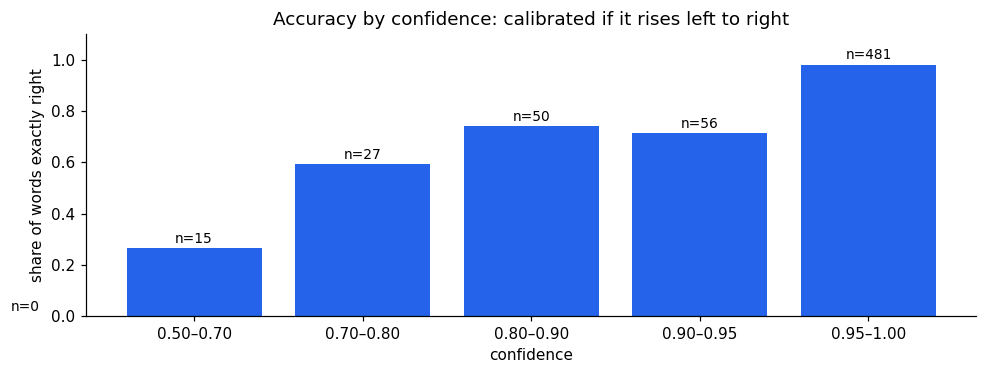

In [6]:
conf = np.array(confs); wrong = np.array([p != t for p, t in zip(preds, truths)])
rows = []
for threshold in (0.5, 0.7, 0.8, 0.9, 0.95):
    flagged = conf < threshold
    rows.append({"flag if confidence <": threshold, "words flagged": flagged.mean(),
                 "errors caught": (flagged & wrong).sum() / max(wrong.sum(), 1),
                 "flagged that are wrong": (flagged & wrong).sum() / max(flagged.sum(), 1)})
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:.2f}"))

bins = np.array([0, 0.5, 0.7, 0.8, 0.9, 0.95, 1.0001])
which = np.digitize(conf, bins) - 1
acc = [1 - wrong[which == b].mean() if (which == b).any() else np.nan for b in range(len(bins) - 1)]
counts = [(which == b).sum() for b in range(len(bins) - 1)]
labels = [f"{bins[b]:.2f}–{min(bins[b + 1], 1):.2f}" for b in range(len(bins) - 1)]
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(labels, acc, color="#2563EB")
for x, (a, n) in enumerate(zip(acc, counts)):
    ax.text(x, (0 if np.isnan(a) else a) + 0.02, f"n={n}", ha="center", fontsize=9)
ax.set_ylim(0, 1.1); ax.set_xlabel("confidence"); ax.set_ylabel("share of words exactly right")
ax.set_title("Accuracy by confidence: calibrated if it rises left to right")
plt.tight_layout(); plt.show()

## 4. End to end: DBNet finds the words, the fine-tuned recognizer reads them

No ground-truth boxes here. Each predicted box is matched to a ground-truth word at IoU ≥ 0.5, one to one.
A ground-truth word counts as read correctly only if it was found **and** its text is exact.

In [7]:
def match(pred_polys, gt_polys, thresh=0.5):
    """Greedy one-to-one matching; returns (pred index, gt index) pairs."""
    pairs, used = [], set()
    for i, p in enumerate(pred_polys):
        scores = [(polygon_iou(p, g), j) for j, g in enumerate(gt_polys) if j not in used]
        if scores:
            iou, j = max(scores)
            if iou >= thresh:
                pairs.append((i, j)); used.add(j)
    return pairs

model = OCRModel(dbnet_path=DBNET, recognizer_path=MODELS[FINE_TUNED])
n_gt = n_pred = n_found = n_exact = 0
matched_p, matched_t = [], []
start = time.time()
for _, image, quads, words in receipts:
    found = model.read(image)
    pairs = match([w["polygon"] for w in found], quads)
    n_gt += len(words); n_pred += len(found); n_found += len(pairs)
    for i, j in pairs:
        matched_p.append(found[i]["text"]); matched_t.append(words[j])
        n_exact += found[i]["text"] == words[j]
seconds = time.time() - start
print(f"detection: {n_found}/{n_gt} words found (recall {n_found / n_gt:.3f}), precision {n_found / max(n_pred, 1):.3f}")
print(f"end to end: {n_exact}/{n_gt} words found and read exactly = {n_exact / n_gt:.1%}")
print(f"CER on the found words: {cer(matched_p, matched_t):.3f} | {seconds / len(receipts):.1f} s per receipt on "
      f"{'GPU' if torch.cuda.is_available() else 'CPU'}")

Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

detection: 597/629 words found (recall 0.949), precision 0.913
end to end: 529/629 words found and read exactly = 84.1%
CER on the found words: 0.041 | 0.9 s per receipt on GPU
